<a href="https://www.kaggle.com/code/angeltrek/tc3002b?scriptVersionId=313688711" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# TC3002B Predicción de Accidente Cerebrovascular
Angel Mauricio Ramírez Herrera | A01710158

El objetivo de este notebook es predecir si un paciente puede sufrir un accidente cerebrovascular a partir de variables clínicas y demográficas. Se comparan cuatro enfoques: dos modelos de machine learning clásico y dos redes neuronales densas, incluyendo un modelo propuesto con conexiones residuales.

La estructura de entrenamiento y guardado de modelos está basada en mi repositorio hecho para la clasificación de género de canciones por la estructura de la letra:
SongTextClassifier. GitHub: https://github.com/Angeltrek/SongTextClassifier

| Variable | Descripción |
|----------|-------------|
| age | Edad del paciente |
| hypertension | Hipertensión (0/1) |
| heart_disease | Enfermedad cardíaca (0/1) |
| ever_married | Estado civil |
| work_type | Tipo de trabajo |
| Residence_type | Tipo de residencia |
| avg_glucose_level | Nivel promedio de glucosa |
| bmi | Índice de masa corporal |
| smoking_status | Tabaquismo |
| stroke | Variable objetivo (1 = tuvo stroke) |


## Importaciones


In [1]:
import os, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization, Add, Activation
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

import kagglehub

MODEL_PATH = '/kaggle/working/models/'
os.makedirs(MODEL_PATH, exist_ok=True)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('Model path:', MODEL_PATH)


2026-04-22 18:03:08.954860: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776880989.350690      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776880989.458084      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776880990.445577      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776880990.445621      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776880990.445624      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Model path: /kaggle/working/models/


## Hiperparámetros

Concentrar los hiperparámetros en un solo lugar hace más fácil ajustarlos sin tener que buscarlos dentro del código de cada modelo. Se decidió ponerlos en constantes porque Random Forest muestra mejores resultados debido a que los datos son muy pocos y el balanceo de clases es deficiente.

In [2]:
LEARNING_RATE = 1e-3
BATCH_SIZE    = 64
EPOCHS        = 100
PATIENCE      = 10

print(f'LR={LEARNING_RATE}  BATCH={BATCH_SIZE}  EPOCHS={EPOCHS}  PATIENCE={PATIENCE}')


LR=0.001  BATCH=64  EPOCHS=100  PATIENCE=10


## Carga del dataset


In [3]:
path = kagglehub.dataset_download('madhavtesting/heart-stroke-dataset')
print('Archivos:', os.listdir(path))

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f'Shape: {df.shape}')
print('\nColumnas:', list(df.columns))
print('\nPrimeras filas:')
df.head()


Archivos: ['healthcare-dataset-stroke-data.csv']
Shape: (1554, 11)

Columnas: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Primeras filas:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Análisis exploratorio

El dataset tiene clase desbalanceada, con alrededor del 52% de los casos sin stroke y solo el 48.07% con stroke. Esto es clínicamente realista pero implica que el accuracy por sí solo no es suficiente para evaluar el modelo.

Observamos que probablemente existe una correlación con la edad cuando existe stroke.

Distribución de la variable objetivo:
stroke
0    807
1    747
Name: count, dtype: int64

Porcentaje de stroke: 48.07%

Valores nulos:
bmi    135
dtype: int64


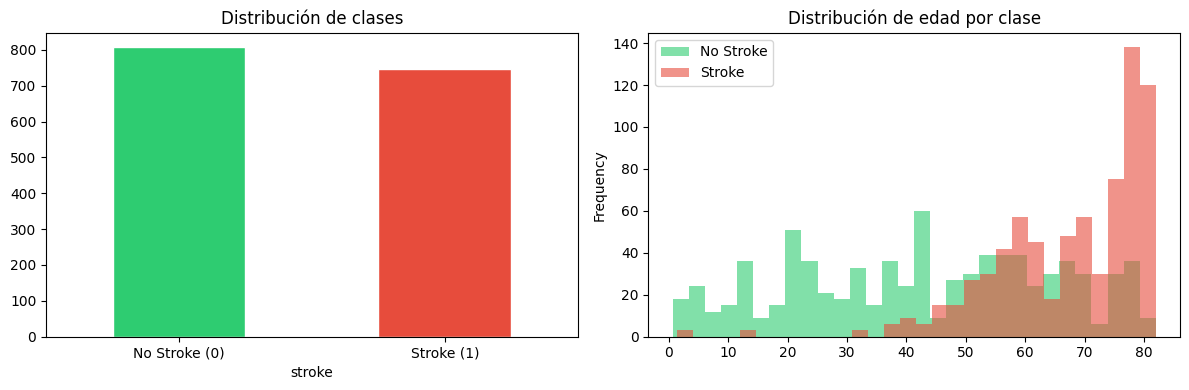

In [4]:
print('Distribución de la variable objetivo:')
print(df['stroke'].value_counts())
print(f'\nPorcentaje de stroke: {df["stroke"].mean()*100:.2f}%')
print('\nValores nulos:')
print(df.isnull().sum()[df.isnull().sum() > 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['stroke'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title('Distribución de clases')
axes[0].set_xticklabels(['No Stroke (0)','Stroke (1)'], rotation=0)
df[df['stroke']==0]['age'].plot(kind='hist', bins=30, alpha=0.6,
    label='No Stroke', ax=axes[1], color='#2ecc71')
df[df['stroke']==1]['age'].plot(kind='hist', bins=30, alpha=0.6,
    label='Stroke', ax=axes[1], color='#e74c3c')
axes[1].set_title('Distribución de edad por clase')
axes[1].legend()
plt.tight_layout(); plt.show()


## Preprocesamiento

La variable bmi tiene valores faltantes. En lugar de imputar con la media o mediana global, se imputa por grupo de género y edad porque el IMC varía considerablemente entre distintos grupos demográficos.

Las variables categóricas se convierten a formato numérico mediante one-hot encoding. Las variables continuas se normalizan con Z-score para que ninguna domine el gradiente por tener una escala numéricamente más grande que las demás.


In [5]:
df = df.drop(columns=['id'], errors='ignore')

# Imputación de bmi por género y grupo de edad
df['age_group'] = pd.cut(df['age'], bins=[0,18,35,50,65,100],
                          labels=['0-18','19-35','36-50','51-65','65+'])
df['bmi'] = df.groupby(['gender','age_group'])['bmi'].transform(
    lambda x: x.fillna(x.median())
)
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df = df.drop(columns=['age_group'])

# Encoding binario
df['gender']       = (df['gender'] == 'Male').astype(int)
df['ever_married'] = (df['ever_married'] == 'Yes').astype(int)

# One-Hot Encoding
df = pd.get_dummies(df,
    columns=['work_type','Residence_type','smoking_status'],
    drop_first=False)

print('Shape tras ETL:', df.shape)
print('Nulos restantes:', df.isnull().sum().sum())


Shape tras ETL: (1554, 19)
Nulos restantes: 0


## Matriz de correlación

Se analiza la correlación entre variables para identificar multicolinealidad y para entender qué variables tienen mayor relación con la variable objetivo.

Se detecta que efectivamente existe una correlación postiva con stroke y age.

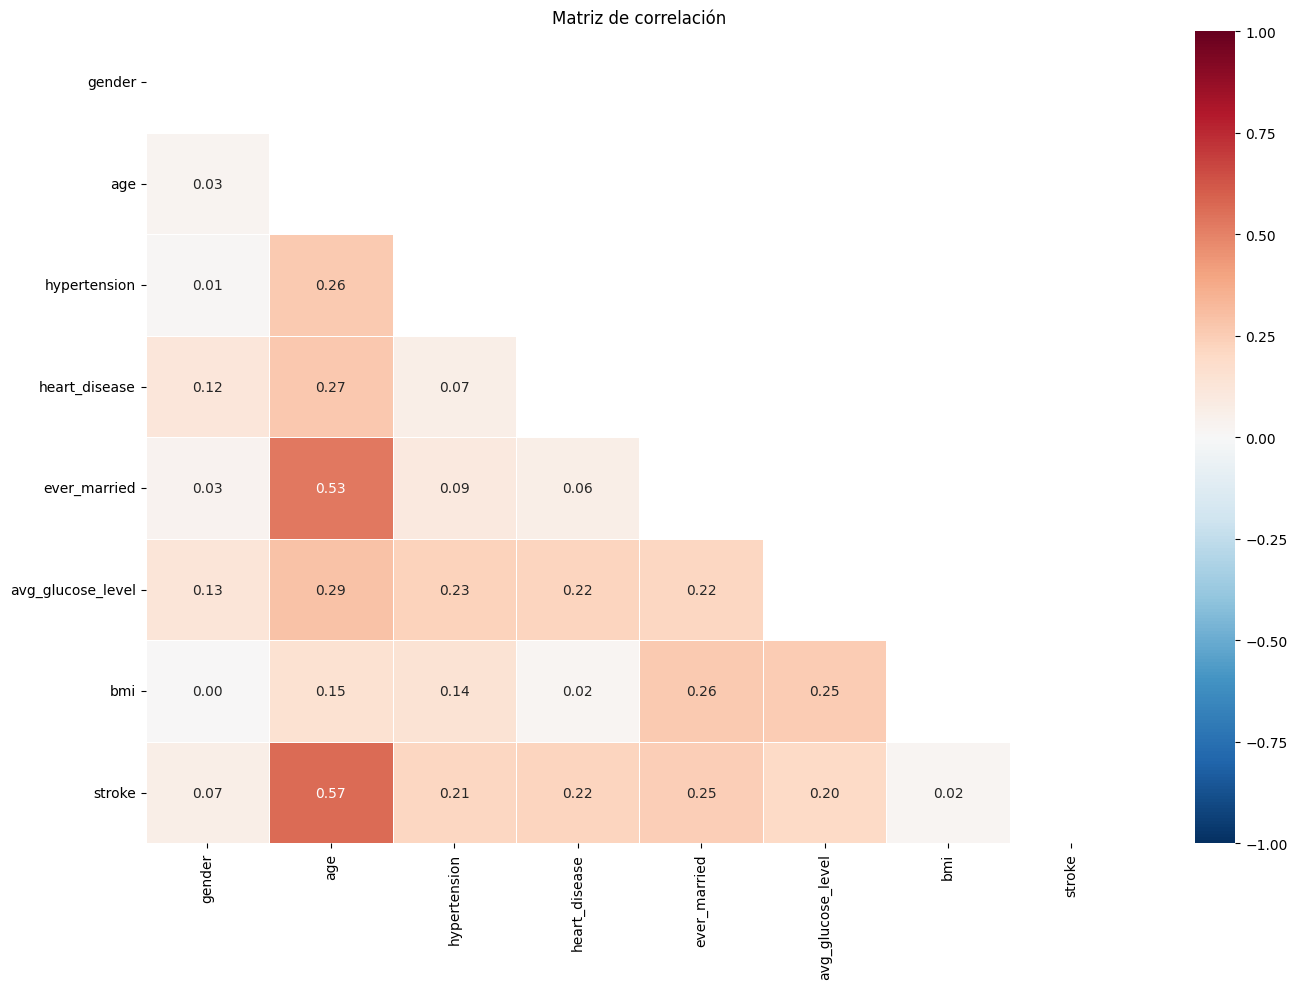


Correlación con stroke (top 8):
stroke               1.000000
age                  0.566150
ever_married         0.248032
heart_disease        0.219241
hypertension         0.214389
avg_glucose_level    0.198236
gender               0.067021
bmi                  0.016499


In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de correlación')
plt.tight_layout(); plt.show()

print('\nCorrelación con stroke (top 8):')
print(corr['stroke'].abs().sort_values(ascending=False).head(9).to_string())


## División train / val / test

El dataset se divide en 60% entrenamiento, 20% validación y 20% prueba. Se usa stratify para mantener la proporción de clases en cada conjunto. El scaler se ajusta únicamente sobre los datos de entrenamiento para evitar filtración de información del conjunto de prueba.


In [7]:
X = df.drop(columns=['stroke'])
y = df['stroke'].values

# Convertir a float32 — requerido por Keras
X = X.apply(pd.to_numeric, errors='coerce').fillna(0).astype(np.float32)

# Normalizar variables continuas ANTES del split
continuous = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# Fit del scaler SOLO sobre train
X_train[continuous] = scaler.fit_transform(X_train[continuous])
X_val[continuous]   = scaler.transform(X_val[continuous])
X_test[continuous]  = scaler.transform(X_test[continuous])

n_features = X_train.shape[1]

print(f'Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}')
print(f'% stroke — Train: {y_train.mean()*100:.1f}%  '
      f'Val: {y_val.mean()*100:.1f}%  Test: {y_test.mean()*100:.1f}%')
print(f'Features: {n_features}')
print(f'Dtypes únicos: {X_train.dtypes.unique()}')


Train: 932  Val: 311  Test: 311
% stroke — Train: 48.1%  Val: 48.2%  Test: 47.9%
Features: 18
Dtypes únicos: [dtype('float32')]


## Funciones de evaluación

Se reportan accuracy, F1 Macro, F1 Weighted y ROC-AUC. Con clases desbalanceadas como este dataset, la métrica más relevante es ROC-AUC porque mide qué tan bien el modelo separa las dos clases independientemente del umbral de decisión.


In [8]:
results = {}

def evaluate(name, y_true, y_pred, y_prob=None, training_time=None):
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro')
    f1_wei = f1_score(y_true, y_pred, average='weighted')
    auc    = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    results[name] = {
        'Accuracy': round(acc,4), 'F1 Macro': round(f1_mac,4),
        'F1 Weighted': round(f1_wei,4),
        'ROC-AUC': round(auc,4) if auc else None,
        'Time(s)': round(training_time,2) if training_time else None
    }
    print(f'\n{"="*55}\n  {name}\n{"="*55}')
    print(f'  Accuracy:    {acc:.4f}')
    print(f'  F1 Macro:    {f1_mac:.4f}')
    print(f'  F1 Weighted: {f1_wei:.4f}')
    if auc: print(f'  ROC-AUC:     {auc:.4f}')
    if training_time: print(f'  Tiempo:      {training_time:.2f}s')
    print()
    print(classification_report(y_true, y_pred,
          target_names=['No Stroke','Stroke']))


def plot_cm(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Stroke','Stroke'],
                yticklabels=['No Stroke','Stroke'])
    plt.title(f'Matriz de Confusión — {name}')
    plt.xlabel('Predicción'); plt.ylabel('Real')
    plt.tight_layout(); plt.show()


## Modelos clásicos

La regresión logística sirve como baseline interpretable. Sus coeficientes indican directamente qué variables aumentan o disminuyen el riesgo de stroke, lo cual es valioso en un contexto clínico.

El Random Forest captura interacciones no lineales entre variables que la regresión logística no puede modelar. Se usa class_weight balanced en ambos modelos para compensar el desbalance de clases sin necesidad de técnicas de resampling.



  Logistic Regression
  Accuracy:    0.7395
  F1 Macro:    0.7394
  F1 Weighted: 0.7391
  ROC-AUC:     0.8417
  Tiempo:      0.03s

              precision    recall  f1-score   support

   No Stroke       0.79      0.69      0.73       162
      Stroke       0.70      0.80      0.75       149

    accuracy                           0.74       311
   macro avg       0.74      0.74      0.74       311
weighted avg       0.75      0.74      0.74       311



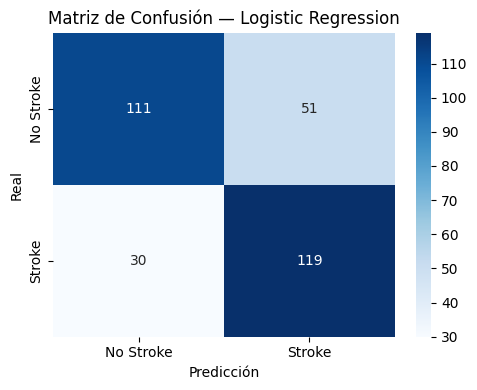

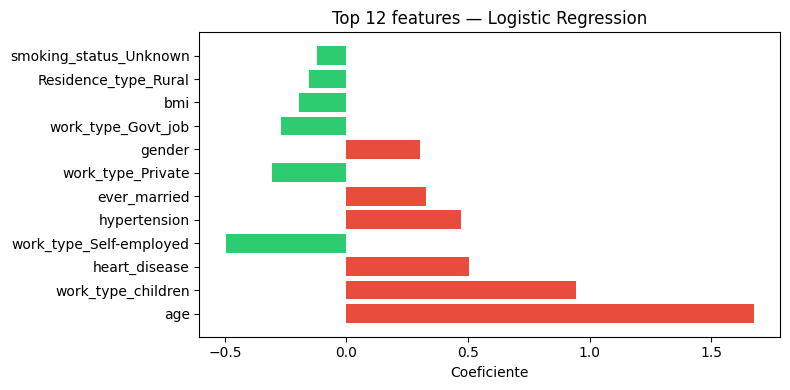


  Random Forest
  Accuracy:    0.9035
  F1 Macro:    0.9035
  F1 Weighted: 0.9036
  ROC-AUC:     0.9815
  Tiempo:      0.87s

              precision    recall  f1-score   support

   No Stroke       0.93      0.88      0.90       162
      Stroke       0.87      0.93      0.90       149

    accuracy                           0.90       311
   macro avg       0.90      0.90      0.90       311
weighted avg       0.91      0.90      0.90       311



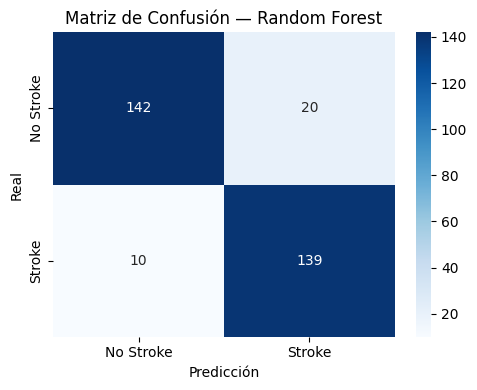

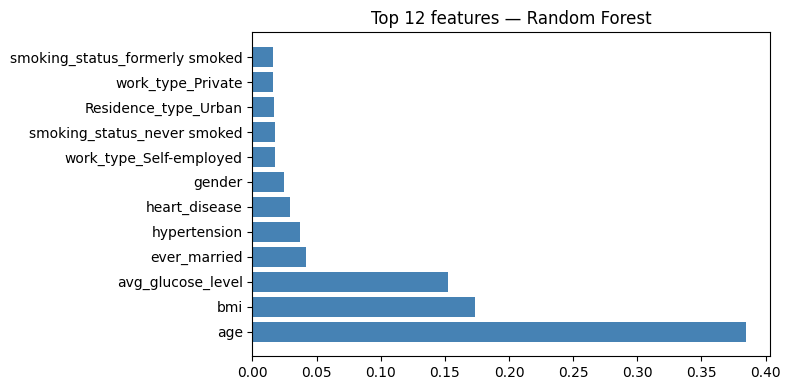

In [9]:
t0 = time.time()
lr = LogisticRegression(max_iter=1000, C=1.0,
                         class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]
t1 = time.time()
evaluate('Logistic Regression', y_test, y_pred_lr, y_prob_lr, t1-t0)
plot_cm('Logistic Regression', y_test, y_pred_lr)

coef_df = pd.DataFrame({'feature': X_train.columns, 'coef': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)
plt.figure(figsize=(8, 4))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['coef'].head(12)]
plt.barh(coef_df['feature'].head(12), coef_df['coef'].head(12), color=colors)
plt.title('Top 12 features — Logistic Regression')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

t0 = time.time()
rf = RandomForestClassifier(n_estimators=300, max_depth=10,
                             class_weight='balanced',
                             n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]
t1 = time.time()
evaluate('Random Forest', y_test, y_pred_rf, y_prob_rf, t1-t0)
plot_cm('Random Forest', y_test, y_pred_rf)

imp_df = pd.DataFrame({'feature': X_train.columns,
                        'importance': rf.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False).head(12)
plt.figure(figsize=(8, 4))
plt.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
plt.title('Top 12 features — Random Forest')
plt.tight_layout()
plt.show()


## Función de entrenamiento

Todos los modelos de red neuronal usan la misma función de entrenamiento para mantener consistencia. El ModelCheckpoint guarda automáticamente el mejor modelo según val_loss, lo que permite cargarlo después en otro archivo sin tener que reentrenar.

Código fuente: https://github.com/Angeltrek/SongTextClassifier/blob/main/documentation/deep_learning_model_improvement.ipynb?short_path=1d19b97


In [10]:
def get_callbacks(model_name):
    return [
        ModelCheckpoint(
            filepath=MODEL_PATH + f'{model_name}.keras',
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]


def train_model(model_to_train, name, learning_rate=LEARNING_RATE,
                epochs=EPOCHS, batch_size=BATCH_SIZE):
    """
    Compila, entrena y evalúa un modelo. Guarda el mejor checkpoint.
    Usa class_weight para compensar el desbalance stroke/no-stroke.
    Retorna (modelo, history).
    """
    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()
    class_weight = {0: 1.0, 1: n_neg / n_pos}

    model_to_train.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    model_to_train.summary()

    t0 = time.time()
    history = model_to_train.fit(
        X_train.values, y_train,
        validation_data=(X_val.values, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight,
        callbacks=get_callbacks(name),
        verbose=1
    )
    t1 = time.time()

    y_prob = model_to_train.predict(X_test.values, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    evaluate(name, y_test, y_pred, y_prob, t1-t0)
    plot_cm(name, y_test, y_pred)

    # Curvas de entrenamiento
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['loss'],         label='Train')
    ax1.plot(history.history['val_loss'],     label='Val')
    ax1.set_title(f'Loss — {name}'); ax1.legend(); ax1.grid(True)
    ax2.plot(history.history['accuracy'],     label='Train')
    ax2.plot(history.history['val_accuracy'], label='Val')
    ax2.set_title(f'Accuracy — {name}'); ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()

    print(f'modelo guardado en: {MODEL_PATH}{name}.keras')
    return model_to_train, history


def load_model(name):
    """Carga un modelo guardado por train_model."""
    model = tf.keras.models.load_model(MODEL_PATH + f'{name}.keras')
    print(f'Modelo cargado: {MODEL_PATH}{name}.keras')
    return model


## Red neuronal base

La primera red neuronal tiene dos capas ocultas con activación ReLU y dropout para regularización. Es el equivalente tabular del CNN en los notebooks de NLP: aprende combinaciones no lineales de los features clínicos sin embeddings ni capas convolucionales.


I0000 00:00:1776881029.982901      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776881029.988791      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "MLP_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

...

Epoch 1/100


I0000 00:00:1776881032.937771     103 service.cc:152] XLA service 0x787d4800d150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776881032.937803     103 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776881032.937807     103 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776881033.347325     103 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/15 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.5312 - loss: 0.7566

I0000 00:00:1776881035.002148     103 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5341 - loss: 0.7341
Epoch 1: val_loss improved from inf to 0.64394, saving model to /kaggle/working/models/MLP_base.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.5345 - loss: 0.7335 - val_accuracy: 0.6624 - val_loss: 0.6439 - learning_rate: 0.0010
Epoch 2/100
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5312 - loss: 0.6876
Epoch 2: val_loss improved from 0.64394 to 0.59458, saving model to /kaggle/working/models/MLP_base.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6458 - loss: 0.6586 - val_accuracy: 0.7074 - val_loss: 0.5946 - learning_rate: 0.0010
Epoch 3/100
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7031 - loss: 0.6056
Epoch 3: val_loss improved from 0.59458 to 0.55868, saving model to /kaggle/working/models/MLP_base.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6973 - loss: 0.6142 - val_accuracy: 0.7138 - val_loss: 0.5587 - learning_rate: 0.0010
Epoch 4/100
 1/15 

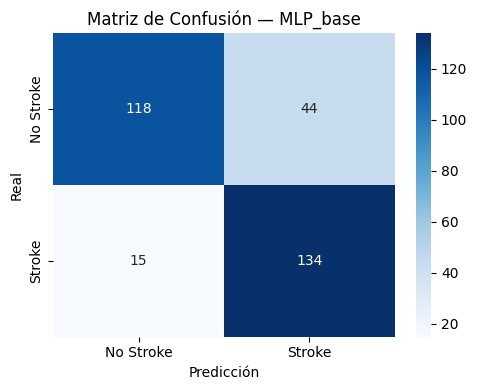

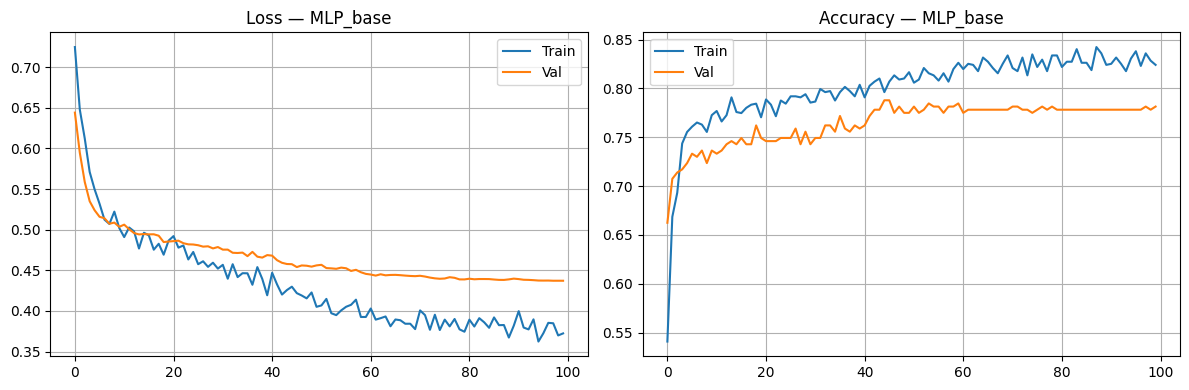

modelo guardado en: /kaggle/working/models/MLP_base.keras


In [11]:
def get_mlp_base():
    inp = Input(shape=(n_features,))
    x   = Dense(64, activation='relu')(inp)
    x   = Dropout(0.3)(x)
    x   = Dense(32, activation='relu')(x)
    x   = Dropout(0.2)(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inp, outputs=out, name='MLP_base')

mlp_base, hist_base = train_model(get_mlp_base(), 'MLP_base')


## Red neuronal con BatchNormalization

Esta arquitectura agrega BatchNormalization después de cada capa densa. La normalización por lotes estabiliza el entrenamiento y permite usar learning rates más altos sin que la red diverja, lo que en la práctica acelera la convergencia.


Model: "MLP_deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.5429 - loss: 0.8695
Epoch 1: val_loss improved from inf to 0.65976, saving model to /kaggle/working/models/MLP_deep.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.5454 - loss: 0.8652 - val_accuracy: 0.7106 - val_loss: 0.6598 - learning_rate: 0.0010
Epoch 2/100
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7031 - loss: 0.6104
Epoch 2: val_loss improved from 0.65976 to 0.64013, saving model to /kaggle/working/models/MLP_deep.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6930 - loss: 0.6126 - val_accuracy: 0.6720 - val_loss: 0.6401 - learning_rate: 0.0010
Epoch 3/100
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7656 - loss: 0.5176
Epoch 3: val_loss improved from 0.64013 to 0.62659, saving model to /kaggle/working/models/MLP_deep.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7262 - loss: 0.5757 - val_accuracy: 0.6913 - val_loss: 0.6266 - learning_rate: 0.0010
Epoch 

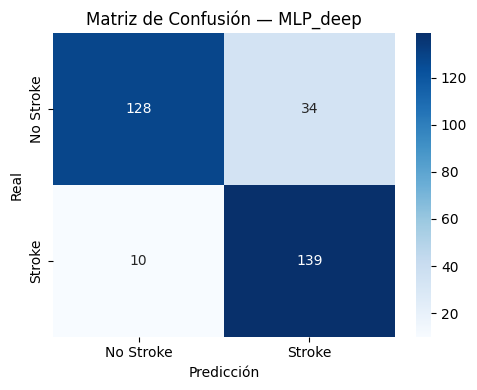

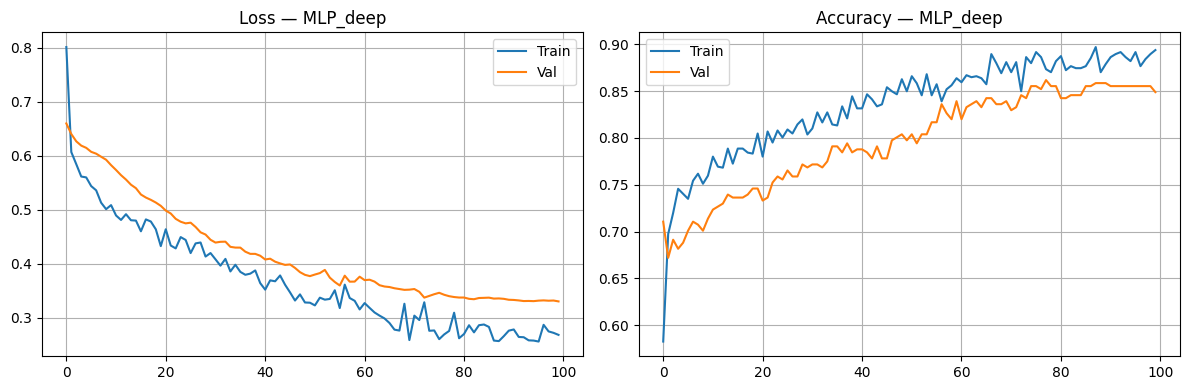

modelo guardado en: /kaggle/working/models/MLP_deep.keras


In [12]:
def get_mlp_deep():
    inp = Input(shape=(n_features,))
    x   = Dense(128, activation='relu')(inp)
    x   = BatchNormalization()(x)
    x   = Dropout(0.4)(x)
    x   = Dense(64, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(0.3)(x)
    x   = Dense(32, activation='relu')(x)
    x   = Dropout(0.2)(x)
    out = Dense(1, activation='sigmoid')(x)
    return Model(inputs=inp, outputs=out, name='MLP_deep')

mlp_deep, hist_deep = train_model(get_mlp_deep(), 'MLP_deep')


## Comparación de modelos



COMPARATIVA FINAL — Heart Stroke Dataset
             Modelo  Accuracy  F1 Macro  F1 Weighted  ROC-AUC  Time(s)
      Random Forest    0.9035    0.9035       0.9036   0.9815     0.87
           MLP_deep    0.8585    0.8583       0.8581   0.9578    25.17
           MLP_base    0.8103    0.8098       0.8094   0.8916    21.25
Logistic Regression    0.7395    0.7394       0.7391   0.8417     0.03


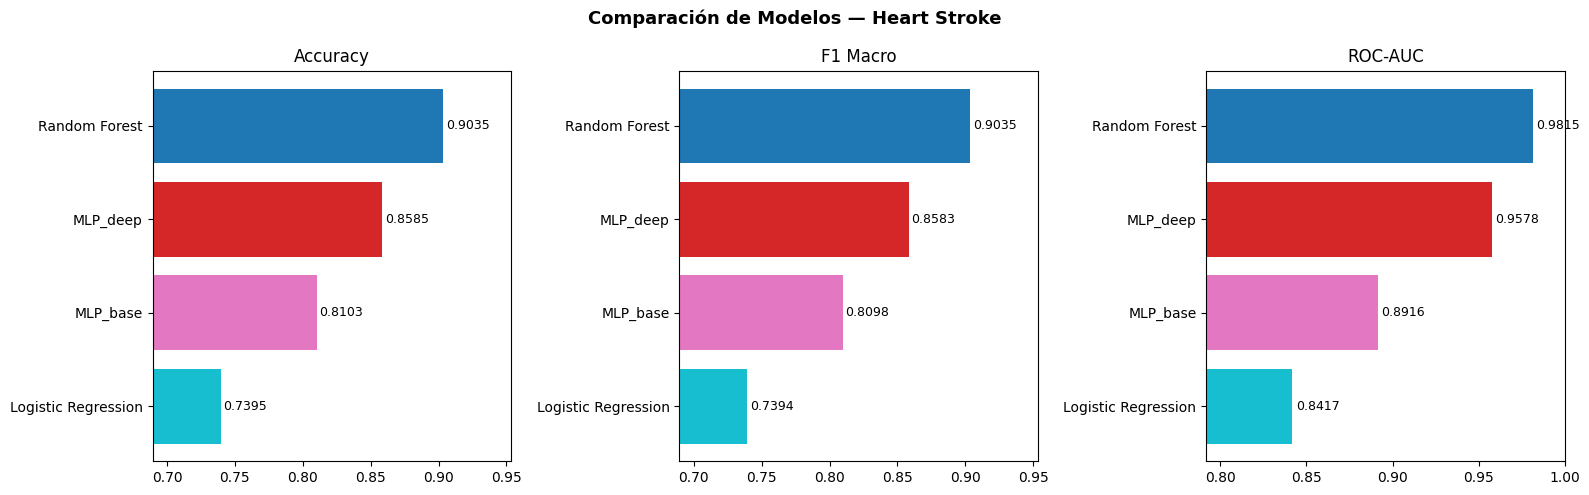

In [13]:
df_res = pd.DataFrame(results).T.reset_index()
df_res.columns = ['Modelo','Accuracy','F1 Macro','F1 Weighted','ROC-AUC','Time(s)']
df_res = df_res.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print('\n' + '='*70)
print('COMPARATIVA FINAL — Heart Stroke Dataset')
print('='*70)
print(df_res.to_string(index=False))
print('='*70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(df_res)))
for ax, metric in zip(axes, ['Accuracy','F1 Macro','ROC-AUC']):
    vals = df_res[metric].astype(float)
    bars = ax.barh(df_res['Modelo'], vals, color=colors)
    ax.set_title(metric)
    ax.set_xlim(max(0, vals.min()-0.05), min(1.0, vals.max()+0.05))
    ax.invert_yaxis()
    for bar, v in zip(bars, vals):
        ax.text(v+0.002, bar.get_y()+bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Comparación de Modelos — Heart Stroke',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## Modelo Mejorado

Como se puede observar en la comparación de modelos, obtenemos que el modelo con mejor desempeño es el Random Forest. Esto tiene sentido debido a la estructura de los datos, son pocos y sus clases no están muy balanceadas, por lo que un random forest sirve mejor que un modelo de deep learning.


  Random Forest Improved
  Accuracy:    0.9550
  F1 Macro:    0.9549
  F1 Weighted: 0.9550
  ROC-AUC:     0.9885
  Tiempo:      0.82s

              precision    recall  f1-score   support

   No Stroke       0.95      0.96      0.96       162
      Stroke       0.96      0.95      0.95       149

    accuracy                           0.95       311
   macro avg       0.96      0.95      0.95       311
weighted avg       0.96      0.95      0.95       311



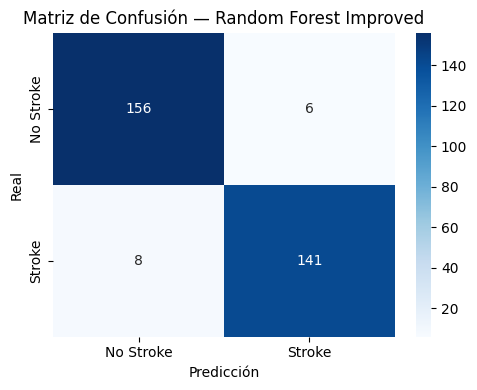

['/kaggle/working/models/rf_improved_model.pkl']

In [14]:
t0 = time.time()
rf_improved = RandomForestClassifier(n_estimators=300, max_depth=20,
                             class_weight='balanced',
                             n_jobs=-1, random_state=42)
rf_improved.fit(X_train, y_train)
y_pred_rf = rf_improved.predict(X_test)
y_prob_rf = rf_improved.predict_proba(X_test)[:,1]
t1 = time.time()
evaluate('Random Forest Improved', y_test, y_pred_rf, y_prob_rf, t1-t0)
plot_cm('Random Forest Improved', y_test, y_pred_rf)

import joblib
joblib.dump(rf_improved, "/kaggle/working/models/rf_improved_model.pkl")

## Cargar modelo guardado

Los modelos se guardan automáticamente durante el entrenamiento. Para usarlos en otro notebook basta con cargarlos desde la ruta donde se guardaron.


In [15]:
print('modelos guardados:')
for f in sorted(os.listdir(MODEL_PATH)):
    size = os.path.getsize(os.path.join(MODEL_PATH, f)) / 1024
    print(f'  {f}  ({size:.1f} KB)')


modelos guardados:
  MLP_base.keras  (70.8 KB)
  MLP_deep.keras  (207.4 KB)
  rf_improved_model.pkl  (7612.3 KB)


## Predicción sobre un paciente nuevo


In [16]:
def predict_stroke(age, hypertension, heart_disease, ever_married,
                    work_type, residence_type, avg_glucose_level,
                    bmi, smoking_status, gender='Male'):
    row = {
        'gender': 1 if gender=='Male' else 0,
        'age': age, 'hypertension': hypertension,
        'heart_disease': heart_disease,
        'ever_married': 1 if ever_married=='Yes' else 0,
        'avg_glucose_level': avg_glucose_level, 'bmi': bmi,
    }
    for wt in ['Govt_job','Never_worked','Private','Self-employed','children']:
        row[f'work_type_{wt}'] = 1 if work_type==wt else 0
    for rt in ['Rural','Urban']:
        row[f'Residence_type_{rt}'] = 1 if residence_type==rt else 0
    for ss in ['Unknown','formerly smoked','never smoked','smokes']:
        row[f'smoking_status_{ss}'] = 1 if smoking_status==ss else 0

    X_new = pd.DataFrame([row]).reindex(columns=X_train.columns, fill_value=0)
    X_new = X_new.astype(np.float32)
    X_new[continuous] = scaler.transform(X_new[continuous])

    print('='*58)
    print(f'Paciente: {age}a, glucosa={avg_glucose_level}, bmi={bmi}')
    print('─'*58)
    prob_lr  = lr.predict_proba(X_new)[0][1]
    prob_rf  = rf.predict_proba(X_new)[0][1]
    prob_b   = float(mlp_base.predict(X_new.values, verbose=0)[0][0])
    prob_d   = float(mlp_deep.predict(X_new.values, verbose=0)[0][0])
    prob_rf_imp = rf_improved.predict_proba(X_new)[0][1]

    for name, prob in [('1. LR',prob_lr),('2. RF',prob_rf),
                        ('3. MLP base',prob_b),('4. MLP deep',prob_d),
                        ('5. RF Mejorado',prob_rf_imp)]:
        label = 'STROKE' if prob>=0.5 else 'No Stroke'
        bar   = '█' * int(prob*20)
        print(f'  {name:20s}: {prob:.3f} {bar:<20} {label}')
    print('='*58)


# Alto riesgo
predict_stroke(72, 1, 1, 'Yes', 'Private', 'Urban',
               228.0, 36.6, 'formerly smoked', 'Male')
print()
# Bajo riesgo
predict_stroke(25, 0, 0, 'No', 'Private', 'Urban',
               85.0, 22.0, 'never smoked', 'Female')


Paciente: 72a, glucosa=228.0, bmi=36.6
──────────────────────────────────────────────────────────
  1. LR               : 0.899 █████████████████    STROKE
  2. RF               : 0.817 ████████████████     STROKE
  3. MLP base         : 0.916 ██████████████████   STROKE
  4. MLP deep         : 0.979 ███████████████████  STROKE
  5. RF Mejorado      : 0.817 ████████████████     STROKE

Paciente: 25a, glucosa=85.0, bmi=22.0
──────────────────────────────────────────────────────────
  1. LR               : 0.068 █                    No Stroke
  2. RF               : 0.038                      No Stroke
  3. MLP base         : 0.010                      No Stroke
  4. MLP deep         : 0.000                      No Stroke
  5. RF Mejorado      : 0.023                      No Stroke


## Referencias

Ramírez Herrera, A. M. (2024). SongTextClassifier: Evidencia de deep learning para Inteligencia Artificial Avanzada para la Ciencia de Datos II. GitHub. https://github.com/Angeltrek/SongTextClassifier

Heart Stroke Dataset. Kaggle. https://www.kaggle.com/datasets/madhavtesting/heart-stroke-dataset

Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. Information Processing & Management, 45(4), 427–437. https://doi.org/10.1016/j.ipm.2009.03.002

Asadi, H., et al. (2023). Evaluating machine learning models for stroke prediction based on clinical variables. Frontiers in Neurology. https://doi.org/10.3389/fneur.2025.1668420

Trigka, M., & Dritsas, E. (2023). Long-term coronary artery disease risk prediction with machine learning models. Sensors, 23(3), 1193. https://doi.org/10.3390/s23031193
